# Visualization of transform matrices

1) [Shape of an element](#shape-of-an-element-of-the-list)
2) [Show positions](#show-positions)
3) [Show translations](#show-translations)
4) [Show quadtrees](#show-quadtrees)
5) [Transform plots to GEOTIFF](#transform-plots-to-geotiff)
6) [Temp](#temp)

In [ ]:
import os
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import pickle
from tqdm import tqdm
import open3d as o3d
import laspy
from plyfile import PlyData, PlyElement
import rasterio
from rasterio.transform import from_origin
from copy import deepcopy

import geopandas as gpd
from shapely.geometry import Point
import pandas as pd

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
# load transforms
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement\results\pyramid_transforms_test.pickle"
with open(src_transforms, 'rb') as f:
    lst_transforms = pickle.load(f)

In [4]:
# print(lst_transforms)
print(len(lst_transforms))
print(len(lst_transforms[4]))

681
3


In [5]:
print(lst_transforms[0][1][0])

lst_levels = set([x[0] for x in lst_transforms])
print(lst_levels)


[2.5010e+06 1.1440e+06 9.7568e+02]
{0, 1, 2, 3, 4, 5}


### Shape of an element of the list:

[level, (min_bound-> list(3), fitness, inlier_rmse, transformation -> array[4,4])]

**transform** = \
[ R | t ] \
[ 0 | 1 ]

**fitness** = "how much overlap you have"
* 1.0 -> all source points matched
* 0.0 -> no overlap, no matching

**inlier_rmse** = "how good the alignment is" (only computed over inliers)
* inliers = points whose distance to a match is < max_correspondence_distance

### Show positions

In [ ]:
# xbase = 2500000
# ybase = 1144000

fig, axs = plt.subplots(len(lst_levels), 1, figsize=(30, len(lst_levels)*7))
for id_lvl, lvl in enumerate(lst_levels):
    data = [x for x in lst_transforms if x[0] == lvl]
    print(len(data))
    size = int(len(data)**0.5)

    x_poses = np.array([x[1][0][0] for x in data])
    y_poses = np.array([x[1][0][1] for x in data])

    list_x_poses = sorted(list(set(x_poses)))
    list_y_poses = sorted(list(set(y_poses)))
    grid = np.zeros((size,size))
    x_poses = x_poses.reshape((size,size))
    for el in data:
        ix = list_x_poses.index(el[1][0][0])
        iy = list_y_poses.index(el[1][0][1])
        transform = el[1][3]
        translation = np.sqrt(np.sum(transform[0:3,3]**2))
        grid[ix,iy] = el[1][0][0] + el[1][0][1]

    y_poses = np.array([x[1][0][1] for x in data]).reshape((size,size))
    axs[id_lvl].imshow(grid)

### Show translations

In [ ]:
xbase = 2500000
ybase = 1144000
# lst_levels = range(3)
fig, axs = plt.subplots(len(lst_levels), 1, figsize=(30, len(lst_levels)*7))
for id_lvl, lvl in enumerate(lst_levels):
    data = [x for x in lst_transforms if x[0] == lvl]
    size = int(len(data)**0.5)
    x_poses = np.array([x[1][0][0] for x in data])
    y_poses = np.array([x[1][0][1] for x in data])
    list_x_poses = sorted(list(set(x_poses)))
    list_y_poses = sorted(list(set(y_poses)))
    grid = np.zeros((size,size))
    x_poses = x_poses.reshape((size,size))
    for el in data:
        ix = list_x_poses.index(el[1][0][0])
        iy = list_y_poses.index(el[1][0][1])
        transform = el[1][3]
        translation = np.sqrt(np.sum(transform[0:3,3]**2))
        grid[ix,iy] = translation
    y_poses = np.array([x[1][0][1] for x in data]).reshape((size,size))
    axs[id_lvl].imshow(grid)
    # axs[id_lvl].imshow(y_poses)
    # Loop over data dimensions and create text annotations.
    # for i in range(size):
    #     for j in range(size):
    #         text = axs[id_lvl].text(j, i, f"{data[i+j][1][0][0] - xbase}\n{data[i+j][1][0][1] - ybase}",
    #                     ha="center", va="center", color="w")

### Show quadtrees

4
0
0
1
1
2
2
3
3


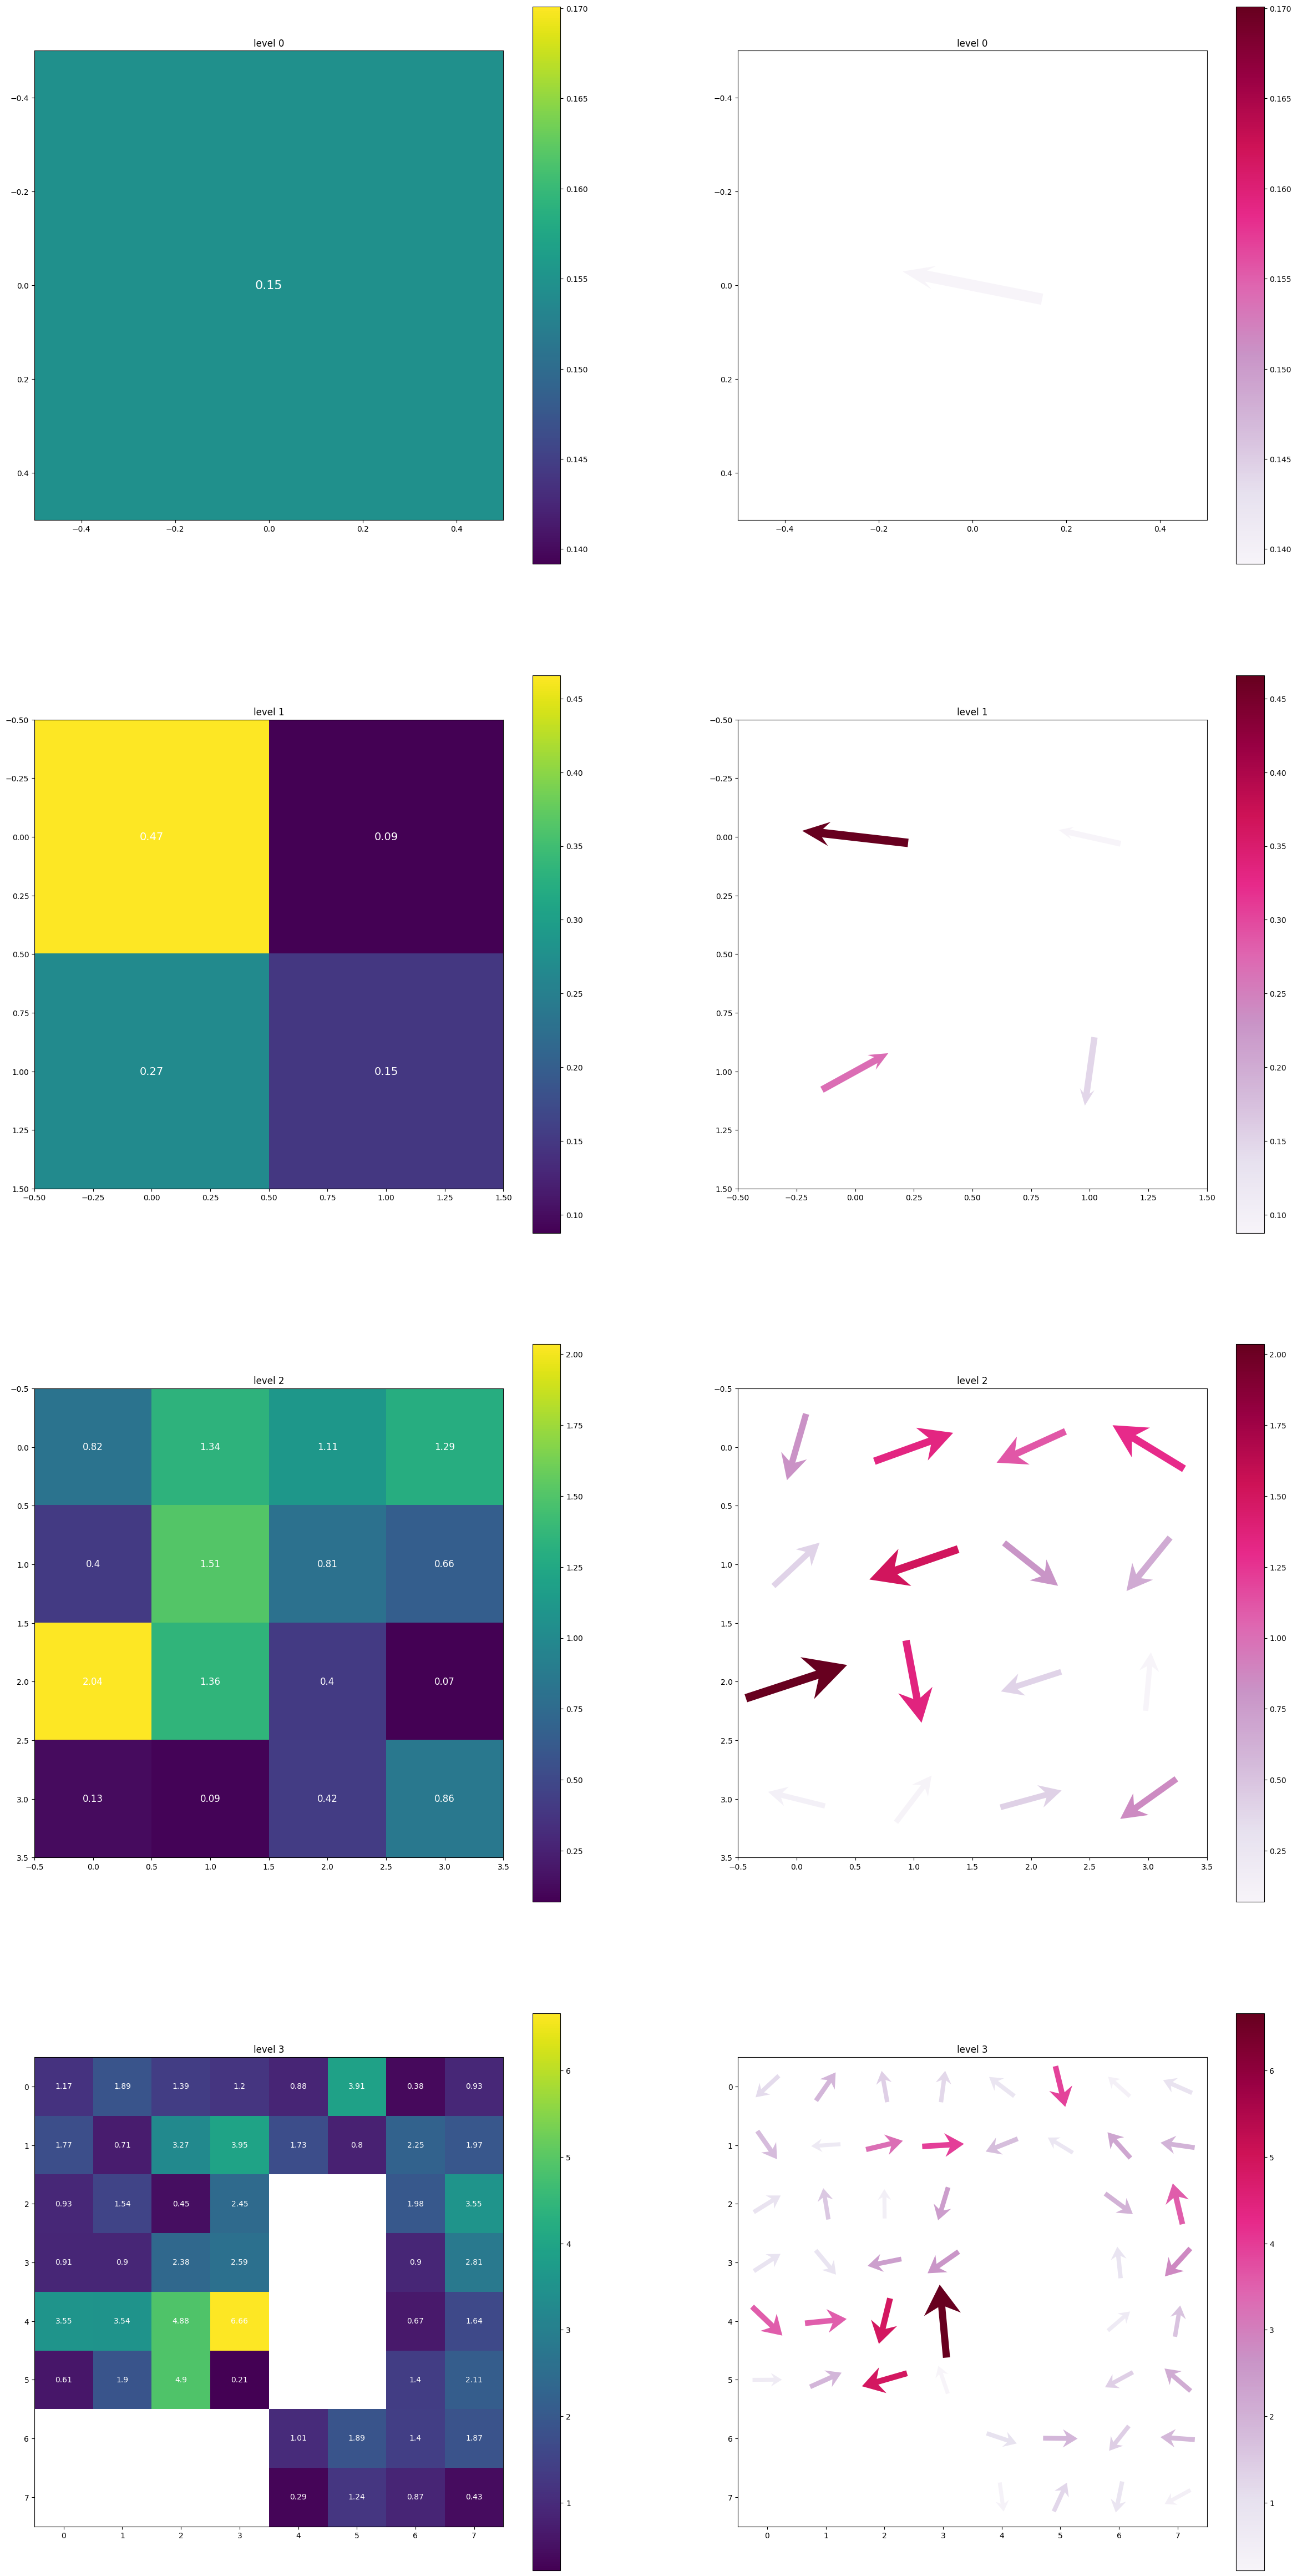

In [36]:
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\temp\results\pyramid_transforms_test.pickle"
src_tile_original = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\temp\swisssurface3d_2018_2589-1169_2056_5728_subsample.ply"

do_save = True

src_res_img = os.path.join(os.path.dirname(src_transforms), 'images')
os.makedirs(src_res_img, exist_ok=True)

tile_original = o3d.io.read_point_cloud(src_tile_original)
z_mean = tile_original.compute_mean_and_covariance()[0][2]
tile_original.translate(np.array([-2589500, -1169500, 0]) - np.array([0, 0, z_mean]))

with open(src_transforms, 'rb') as f:
    lst_transforms = pickle.load(f)

data = []
lvl = 0
storage = []
# print(lst_transforms)
num_lvl = len(set([x[0] for x in lst_transforms]))
num_ax_lvl = num_lvl - lvl
print(num_ax_lvl)
# lvl = 0
ax_lvl = 0
fig, axs = plt.subplots(num_ax_lvl, 2, figsize=(30, num_ax_lvl*15), squeeze=False)
# while len(storage) < len(lst_transforms):
storage = [x for x in lst_transforms if x[0] < lvl]
while ax_lvl < num_ax_lvl:
    print(ax_lvl)
    X, Y, U, V, norms = [], [], [], [] , []

    # transfert element of current lvl from storage to data 
    for el in [x for x in lst_transforms if x[0] == lvl]:
        storage.append(el)
    data = [x for x in storage if x[0] == lvl or x[-1] == True]

    size = 2**lvl
    x_poses = np.array([x[1][0]['min_bound'][0] for x in data])
    y_poses = np.array([x[1][0]['min_bound'][1] for x in data])
    list_x_poses = sorted(list(set(x_poses)))
    list_y_poses = sorted(list(set(y_poses)))
    grid = np.zeros((size,size))
    for el in data:
        bbox_dict = el[1][0]
        bbox = o3d.geometry.AxisAlignedBoundingBox(
            min_bound=np.array(bbox_dict["min_bound"]),
            max_bound=np.array(bbox_dict["max_bound"])
        )
        
        ix = size - list_y_poses.index(bbox_dict["min_bound"][1]) - 1
        iy = list_x_poses.index(bbox_dict["min_bound"][0])
        transform = el[1][3]

        # === HEATMAP ===
        # translation:
        cropped_tile = tile_original.crop(bbox)
        center = np.vstack([np.mean(np.array(cropped_tile.points), axis=0).reshape((3,1)), np.array([1])])
        translated = np.linalg.matmul(transform, center)
        norm = float(np.linalg.norm(translated - center))
        norm2d = float(np.linalg.norm(translated[0:2] - center[0:2]))
        delta = 2**(lvl - el[0])
        # grid[ix:ix+delta,iy:iy+delta] = norm

        if delta > 1:
            # print(ix, iy)
            # print(delta)
            # print(ix*delta, (ix+1)*delta)
            # print(iy*delta, (iy+1)*delta)
            # print('---')
            grid[ix-1:ix+delta,iy:iy+delta] = -9999
        else:
            grid[ix,iy] = norm

            # === QUIVER ===
            # translation:
            norms.append(norm)
            if norm > 0:
                direction = (translated[0:2] - center[0:2]) / norm2d 
            else:
                direction = np.zeros((2,1))
                # print(f"Norm = 0 for {ix} - {iy}")

            # store vector at tile center
            cx = iy
            cy = ix

            X.append(cx)
            Y.append(cy)
            U.append(direction[0])
            V.append(-direction[1])  # minus because imshow flips Y axis
        
    X, Y, U, V, norms = np.array(X), np.array(Y), np.array(U), np.array(V), np.array(norms)
    upper_limit = np.quantile(grid, 0.99) * 1.5
    print(ax_lvl)
    axs[ax_lvl, 0].set_title(f'level {lvl}')
    axs[ax_lvl, 1].set_title(f'level {lvl}')
    lvl_factor = np.clip(lvl/num_lvl * 3, 0.5, 3)

    # === SHOW HEATMAP ===
    # img_size = np.clip(4*lvl, 4, 30)
    # fig, ax = plt.subplots(1,1,figsize=(img_size, img_size), dpi=300)
    # fig.patch.set_alpha(0)
    # ax.patch.set_alpha(0)
    mask_extremes = np.array(grid >= upper_limit)
    mask_bad = grid == -9999
    grid_good = np.ma.masked_where(mask_bad, grid)
    cmap = plt.get_cmap("viridis")
    cmap.set_over('red')
    cmap.set_bad(color=(0,0,0,0))
    im = axs[ax_lvl, 0].imshow(grid_good, cmap=cmap, vmin=np.min(norms), vmax=upper_limit if np.sum(mask_extremes) > 0 else np.max(grid))  # normal values
    axs[ax_lvl, 0].patch.set_alpha(0)
    # mask_extremes = np.array(grid >= upper_limit)
    # grid_normal = np.ma.masked_where(mask_extremes, grid)
    # grid_extreme = np.ma.masked_where(~mask_extremes, grid)
    # cmap = plt.get_cmap("viridis")
    # cmap.set_over('red')
    # im = axs[ax_lvl, 0].imshow(grid, cmap=cmap, vmin=np.min(norms), vmax=upper_limit if np.sum(mask_extremes) > 0 else np.max(grid))  # normal values
    # if np.sum(mask_extremes) > 0:
    #     cmap = plt.cm.coolwarm.copy()
    #     cmap.set_over('red')
    #     axs[lvl, 0].imshow(grid_extreme, cmap=cmap, vmin=upper_limit, vmax=grid.max())

    # im = axs[lvl, 0].imshow(np.where(~mask_extremes, grid,0))
    # axs[lvl, 0].imshow(np.where(mask_extremes, grid,0))
    cbar = axs[ax_lvl, 0].figure.colorbar(im, ax=axs[ax_lvl, 0])

    # Loop over data dimensions and create text annotations.
    fontsizes=[16, 14, 12, 10, 6, 4, 2, 1, 0.5]
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            text = axs[ax_lvl, 0].text(j, i, round(grid[i, j], 2),
                        ha="center", va="center", color="w", fontsize=fontsizes[lvl])
            
    # === SHOW QUIVER ===
    mask_extremes = (norms >= upper_limit)
    # norms = np.clip(norms, 0, upper_limit)
    axs[ax_lvl, 1].imshow(np.zeros(grid.shape), cmap="binary")
    # bins = [0, 0.1, 0.2, 0.5, 1.0, 2.0,]  # adjust to your data
    # print(norms)
    # bins = np.arange(0, np.max(norms) * 1.1, np.max(norms)/(10-1e-6))
    bins = np.arange(0, upper_limit*1.1, upper_limit/(10-1e-6))
    # print(upper_limit)
    # print(bins)
    importance_factor = list(np.arange(1, 2, 1/10))
    importance_factor.append(2.5) # for extreme values
    level_scaling = np.max([3 - lvl, 1])
    # scales = np.arange(2, 0.001, -1.999/10)
    scales = np.arange(2, 0.5, -1.5/10) * level_scaling
    arrow_heads_w_l = [(x,y) for x,y in zip(np.arange(3,0.1,-2.9/10), np.arange(5,0.1,-4.9/10))]

    for i in range(bins.shape[0] - 1):
        mask = (norms >= bins[i]) & (norms < bins[i+1])
        w = 0.03/size * lvl_factor * importance_factor[i]
        qu = axs[ax_lvl,1].quiver(
            X[mask], Y[mask], U[mask], V[mask], norms[mask],
            scale=scales[i],          # adjust this!
            scale_units='xy',
            angles='xy',
            pivot='middle',
            width=w,
            headwidth=3 / 1.1**lvl * (importance_factor[i]+0.5) / level_scaling,
            headlength=4 / 1.3**lvl * (importance_factor[i]+0.5) / level_scaling,
            headaxislength= 3 / 1.3**lvl * (importance_factor[i]+0.5) / level_scaling,
            cmap="PuRd",
            norm=mcolors.Normalize(vmin=np.min(norms), vmax=upper_limit if np.sum(mask_extremes) > 0 else np.max(norms))
        )
    
    # show extreme values
    factors = [1.1, 1.2, 1.3, 1.4, 1.5]
    # print("Level: ", lvl)
    # for f in factors:
    #     mask = (norms >= np.quantile(grid, 0.99) * f)
    #     print(f"Number of extrems (with val {f}): ", np.sum(mask))
    # print('-----')
    axs[ax_lvl, 1].quiver(
        X[mask_extremes], Y[mask_extremes], U[mask_extremes], V[mask_extremes],
        color='#42067e',
        scale=scales[-1],          # adjust this!
        scale_units='xy',
        angles='xy',
        pivot='middle',
        width=0.03/size * lvl_factor * importance_factor[-1],
        headwidth=3 / 1.1**lvl * (importance_factor[-1]+0.5) / level_scaling,
        headlength=4 / 1.3**lvl * (importance_factor[-1]+0.5) / level_scaling,
        headaxislength=3 / 1.3**lvl * (importance_factor[-1]+0.5) / level_scaling,
    )


    cbar = axs[ax_lvl, 1].figure.colorbar(qu, ax=axs[ax_lvl, 1])
    lvl += 1
    ax_lvl += 1
    if do_save:
        plt.savefig(os.path.join(src_res_img, 'results.png'), dpi=300)

7


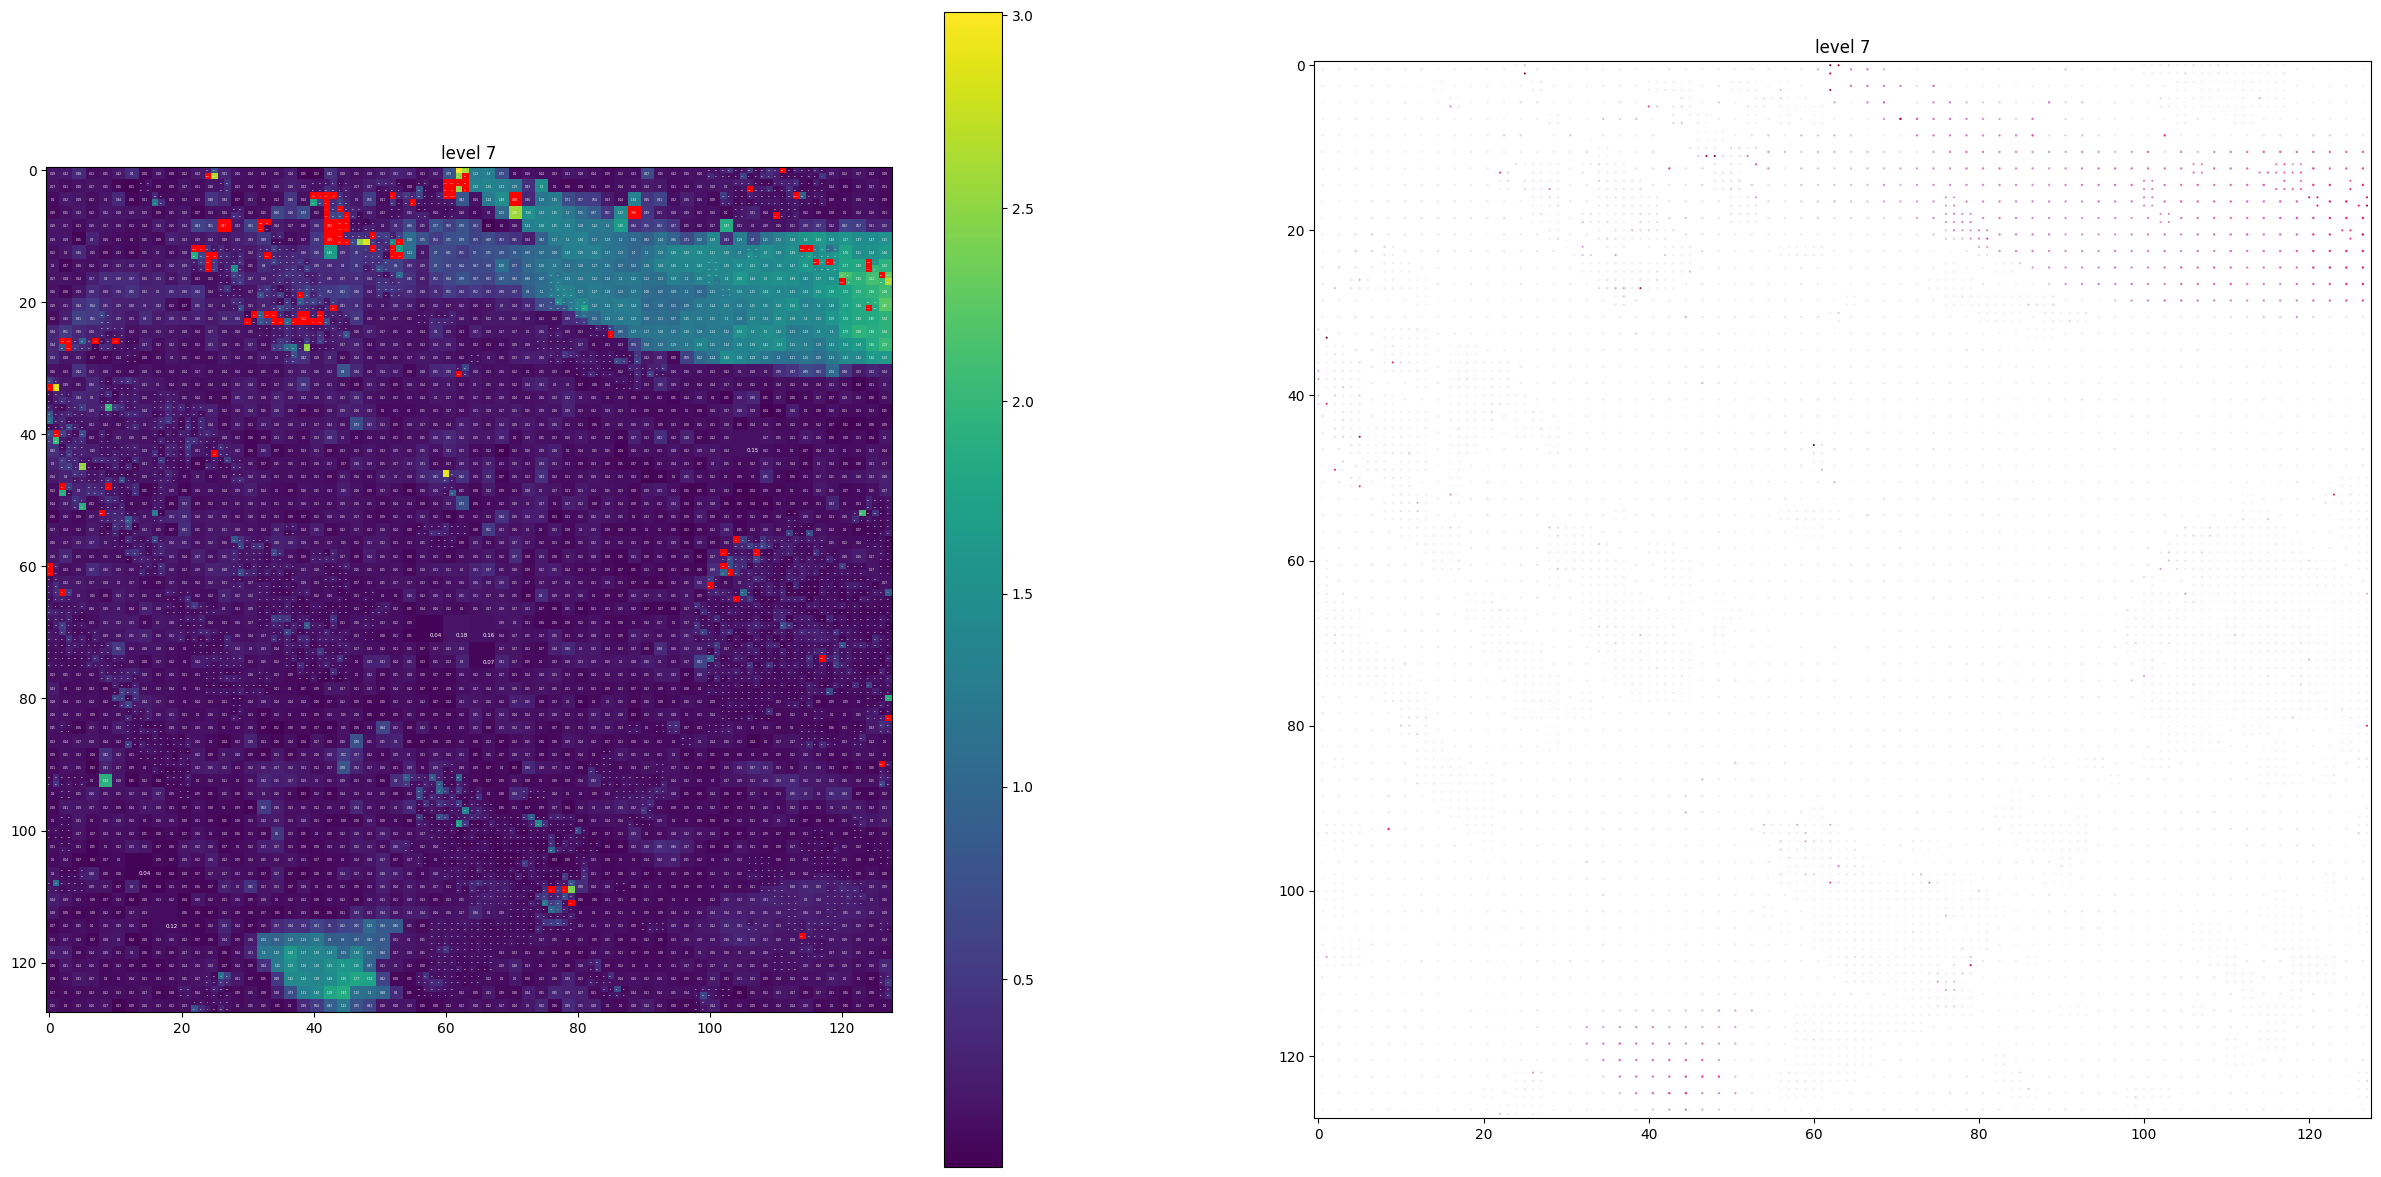

In [25]:
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\temp\results\pyramid_transforms_test.pickle"
# src_tile_original = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\temp\swisssurface3d_2018_2589-1169_2056_5728_subsample.ply"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement_real_spacing\2589_1169\results\pyramid_transforms_test.pickle"
# src_tile_original = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement_real_spacing\2589_1169\swisssurface3d_2018_2589-1169_2056_5728.ply"
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_min_points\3000_max_lvl_7\results\pyramid_transforms_test.pickle"
src_tile_original = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_min_points\3000_max_lvl_7\swisssurface3d_2018_2589-1169_2056_5728.ply"


do_save = True

src_res_img = os.path.join(os.path.dirname(src_transforms), 'images')
os.makedirs(src_res_img, exist_ok=True)

tile_original = o3d.io.read_point_cloud(src_tile_original)
z_mean = tile_original.compute_mean_and_covariance()[0][2]
tile_original.translate(np.array([-2589500, -1169500, 0]) - np.array([0, 0, z_mean]))

with open(src_transforms, 'rb') as f:
    lst_transforms = pickle.load(f)

data = []
lvl = 7
storage = []
num_lvl = len(set([x[0] for x in lst_transforms]))
num_ax_lvl = num_lvl - lvl
ax_lvl = 0
fig, axs = plt.subplots(num_ax_lvl, 2, figsize=(30, num_ax_lvl*15), squeeze=False)
storage = [x for x in lst_transforms if x[0] < lvl]

while lvl < num_lvl:
    print(lvl)
    data = [x for x in lst_transforms if (x[0] < lvl and x[-1] == True) or x[0] == lvl]
    size = 2**lvl
    grid = np.zeros((size,size))
    x_poses = np.array([x[1][0]['min_bound'][0] for x in data])
    y_poses = np.array([x[1][0]['min_bound'][1] for x in data])
    list_x_poses = sorted(list(set(x_poses)))
    list_y_poses = sorted(list(set(y_poses)))

    cmap = plt.get_cmap("viridis")
    cmap.set_over('red')
    list_texts = []
    X, Y, U, V, norms, lvls = [], [], [], [] , [], []
    for el in data:
        el_lvl = el[0]
        bbox_dict = el[1][0]
        bbox = o3d.geometry.AxisAlignedBoundingBox(
            min_bound=np.array(bbox_dict["min_bound"]),
            max_bound=np.array(bbox_dict["max_bound"])
        )
        
        delta = 2**(lvl - el_lvl)
        ix = size - list_y_poses.index(bbox_dict["min_bound"][1]) - delta
        iy = list_x_poses.index(bbox_dict["min_bound"][0])

        transform = el[1][3]

        # === HEATMAP ===
        # translation:
        cropped_tile = tile_original.crop(bbox)
        center = np.vstack([np.mean(np.array(cropped_tile.points), axis=0).reshape((3,1)), np.array([1])])
        translated = np.linalg.matmul(transform, center)
        norm = float(np.linalg.norm(translated - center))
        norm2d = float(np.linalg.norm(translated[0:2] - center[0:2]))
        grid[ix:ix+delta, iy:iy+delta] = norm
        cx = iy + np.clip(delta-1.5, 0, None)
        cy = ix + np.clip(delta-1.5, 0, None)
        list_texts.append((cx,cy,norm, el_lvl))

        # === QUIVER ===
        # translation:
        norms.append(norm)
        lvls.append(el_lvl)
        if norm > 0:
            direction = (translated[0:2] - center[0:2]) / norm2d 
        else:
            direction = np.zeros((2,1))
            print(f"Norm = 0 for {ix} - {iy}")

        # store vector at tile center
        X.append(cx)
        Y.append(cy)
        U.append(direction[0])
        V.append(-direction[1])  # minus because imshow flips Y axis
        
    X, Y, U, V, norms, lvls = np.array(X), np.array(Y), np.array(U), np.array(V), np.array(norms), np.array(lvls)
    upper_limit = np.quantile(grid, 0.99) * 1.5

    axs[ax_lvl, 0].set_title(f'level {lvl}')
    axs[ax_lvl, 1].set_title(f'level {lvl}')
    lvl_factor = np.clip(lvl/num_lvl * 3, 0.5, 3)

    # === SHOW HEATMAP ===
    mask_extremes = np.array(grid >= upper_limit)
    im = axs[ax_lvl, 0].imshow(
        grid, 
        cmap=cmap, 
        vmin=np.min(grid), 
        vmax=upper_limit if np.sum(mask_extremes) > 0 else np.max(grid),
        interpolation='none',
        )
    
    cbar = axs[ax_lvl, 0].figure.colorbar(im, ax=axs[ax_lvl, 0])

    # Loop over data dimensions and create text annotations.
    fontsizes=[16, 14, 12, 10, 6, 4, 2, 1, 0.5]
    for el in list_texts:
        text = axs[ax_lvl, 0].text(
            el[0], 
            el[1], 
            round(el[2], 2),
            ha="center", va="center", color="w", fontsize=fontsizes[el[3]])
        
    # === SHOW QUIVER ===
    mask_extremes = (norms >= upper_limit)
    # norms = np.clip(norms, 0, upper_limit)
    axs[ax_lvl, 1].imshow(np.zeros(grid.shape), cmap="binary")
    # bins = [0, 0.1, 0.2, 0.5, 1.0, 2.0,]  # adjust to your data
    # print(norms)
    # bins = np.arange(0, np.max(norms) * 1.1, np.max(norms)/(10-1e-6))
    bins = np.arange(0, upper_limit*1.1, upper_limit/(10-1e-6))
    # print(upper_limit)
    # print(bins)
    cmaps = []
    importance_factor = list(np.arange(1, 2, 1/10))
    importance_factor.append(2.5) # for extreme values
    level_scaling = np.max([3 - lvl, 1])
    # scales = np.arange(2, 0.001, -1.999/10)
    scales = np.arange(2, 0.5, -1.5/10) * level_scaling
    arrow_heads_w_l = [(x,y) for x,y in zip(np.arange(3,0.1,-2.9/10), np.arange(5,0.1,-4.9/10))]

    # print(set(lvls))
    # print(lvls)
    for qulvl in set(lvls):
        # print(qulvl)
        # print(np.sum(lvls == qulvl))
        # break
        for i in range(bins.shape[0] - 1):
            mask = (norms >= bins[i]) & (norms < bins[i+1]) & (lvls == qulvl)
            if np.sum(mask) == 0:
                continue
            # w = 0.03/size * lvl_factor * importance_factor[i]
            w = 0.015 / qulvl
            # print(qulvl, i)
            # print('width', w)
            # print('scale', scales[i])
            # print('---')
            qu = axs[ax_lvl,1].quiver(
                X[mask], Y[mask], U[mask], V[mask], norms[mask],
                # scale=scales[i],          # adjust this!
                scale=(qulvl-1),
                scale_units='xy',
                angles='xy',
                pivot='middle',
                width=w,
                # headwidth=3 / 1.1**lvl * (importance_factor[i]+0.5) / level_scaling,
                # headlength=4 / 1.3**lvl * (importance_factor[i]+0.5) / level_scaling,
                # headaxislength= 3 / 1.3**lvl * (importance_factor[i]+0.5) / level_scaling,
                cmap="PuRd",
                norm=mcolors.Normalize(vmin=np.min(norms), vmax=upper_limit if np.sum(mask_extremes) > 0 else np.max(norms))
            )

    # # show extreme values
    # factors = [1.1, 1.2, 1.3, 1.4, 1.5]
    # # print("Level: ", lvl)
    # # for f in factors:
    # #     mask = (norms >= np.quantile(grid, 0.99) * f)
    # #     print(f"Number of extrems (with val {f}): ", np.sum(mask))
    # # print('-----')
    # axs[ax_lvl, 1].quiver(
    #     X[mask_extremes], Y[mask_extremes], U[mask_extremes], V[mask_extremes],
    #     color='#42067e',
    #     scale=scales[-1],          # adjust this!
    #     scale_units='xy',
    #     angles='xy',
    #     pivot='middle',
    #     width=0.03/size * lvl_factor * importance_factor[-1],
    #     headwidth=3 / 1.1**lvl * (importance_factor[-1]+0.5) / level_scaling,
    #     headlength=4 / 1.3**lvl * (importance_factor[-1]+0.5) / level_scaling,
    #     headaxislength=3 / 1.3**lvl * (importance_factor[-1]+0.5) / level_scaling,
    # )
    lvl += 1
    ax_lvl += 1

    # # if do_save:
    # #     plt.savefig(os.path.join(src_res_img, 'results.png'), dpi=300)

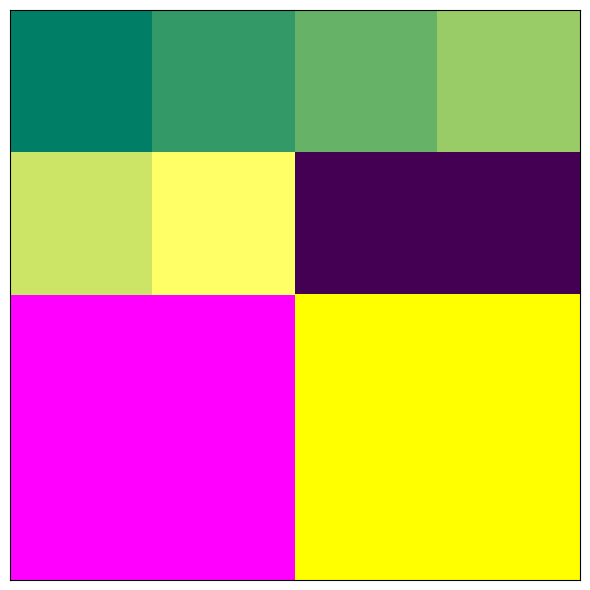

In [13]:
import numpy as np
import matplotlib.pyplot as plt

grids = [
    np.arange(1).reshape((1,1)),
    np.arange(4).reshape((2,2)),
    np.arange(16).reshape((4,4)),
]

masks = [
    (grids[0] > 999),
    (grids[1] < 2),
    (grids[2] > 5),
]

cmaps = ['viridis', 'spring', 'summer']

fig, ax = plt.subplots(figsize=(6, 6))

for i in range(len(grids)):
    cmap = plt.get_cmap(cmaps[i]).copy()
    cmap.set_bad((0, 0, 0, 0))  # transparent masked values

    grid = np.ma.masked_where(masks[i], grids[i])

    ax.imshow(
        grid,
        cmap=cmap,
        interpolation='none',
        extent=(0, 1, 0, 1),  # 👈 aligns all grids
        zorder=i              # 👈 ensures proper stacking
    )

ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

### Transform plots to GEOTIFF

In [ ]:
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\temp\results\pyramid_transforms_test.pickle"
src_tile_original = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\temp\swisssurface3d_2018_2589-1169_2056_5728_subsample.ply"
do_save = True

src_res_img = os.path.join(os.path.dirname(src_transforms), 'images')
os.makedirs(src_res_img, exist_ok=True)

tile_original = o3d.io.read_point_cloud(src_tile_original)
bbox_original = tile_original.get_axis_aligned_bounding_box()
minx, miny, _ = bbox_original.get_min_bound()
maxx, maxy, _ = bbox_original.get_max_bound()

# remove offset
z_mean = tile_original.compute_mean_and_covariance()[0][2]
tile_original.translate(np.array([-2589500, -1169500, 0]) - np.array([0, 0, z_mean]))

with open(src_transforms, 'rb') as f:
    lst_transforms = pickle.load(f)

data = []
lvl = 0
storage = []
num_lvl = len(set([x[0] for x in lst_transforms]))
while len(storage) < len(lst_transforms):
    X, Y, U, V, norms = [], [], [], [] , []

    # transfert element of current lvl from storage to data 
    for el in [x for x in lst_transforms if x[0] == lvl]:
        storage.append(el)
    data = [x for x in storage if x[0] == lvl or x[-1] == True]

    size = 2**lvl
    x_poses = np.array([x[1][0]['min_bound'][0] for x in data])
    y_poses = np.array([x[1][0]['min_bound'][1] for x in data])
    list_x_poses = sorted(list(set(x_poses)))
    list_y_poses = sorted(list(set(y_poses)))
    grid = np.zeros((size,size))
    for el in data:
        bbox_dict = el[1][0]
        bbox = o3d.geometry.AxisAlignedBoundingBox(
            min_bound=np.array(bbox_dict["min_bound"]),
            max_bound=np.array(bbox_dict["max_bound"])
        )
        # min_bound = bbox.get_min_bound()
        
        ix = size - list_y_poses.index(bbox_dict["min_bound"][1]) - 1
        iy = list_x_poses.index(bbox_dict["min_bound"][0])

        transform = el[1][3]

        # === HEATMAP ===
        # translation:
        cropped_tile = tile_original.crop(bbox)
        center = np.vstack([np.mean(np.array(cropped_tile.points), axis=0).reshape((3,1)), np.array([1])])
        translated = np.linalg.matmul(transform, center)
        norm = float(np.linalg.norm(translated - center))
        norm2d = float(np.linalg.norm(translated[0:2] - center[0:2]))
        delta = 2**(lvl - el[0])
        # grid[ix:ix+delta,iy:iy+delta] = norm

        if delta > 1:
            grid[ix:ix+delta,iy:iy+delta] = -9999
        else:
            grid[ix:ix+delta,iy:iy+delta] = norm


            # === QUIVER ===
            # translation:
            norms.append(norm)
            if norm > 0:
                direction = (translated[0:2] - center[0:2]) / norm2d 
            else:
                direction = np.zeros((2,1))
                print(f"Norm = 0 for {ix} - {iy}")

            # store vector at tile center
            cx = iy
            cy = ix

            X.append(cx)
            Y.append(cy)
            U.append(direction[0])
            V.append(-direction[1])  # minus because imshow flips Y axis
        
    X, Y, U, V, norms = np.array(X), np.array(Y), np.array(U), np.array(V), np.array(norms)
    upper_limit = np.quantile(grid, 0.99) * 1.5

    lvl_factor = np.clip(lvl/num_lvl * 3, 0.5, 3)

    # === SHOW HEATMAP ===
    img_size = np.clip(4*lvl, 4, 30)
    fig, ax = plt.subplots(1,1,figsize=(img_size, img_size), dpi=300)
    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    mask_extremes = np.array(grid >= upper_limit)
    mask_bad = grid == -9999
    grid_good = np.ma.masked_where(mask_bad, grid)
    cmap = plt.get_cmap("viridis")
    cmap.set_over('red')
    cmap.set_bad(color=(0,0,0,0))
    im = ax.imshow(grid_good, cmap=cmap, vmin=np.min(norms), vmax=upper_limit if np.sum(mask_extremes) > 0 else np.max(grid))  # normal values

    # Loop over data dimensions and create text annotations.
    fontsizes=[16, 14, 12, 10, 6, 4, 2]
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            if grid[i,j] > -np.inf:
                text = ax.text(j, i, round(grid[i, j], 2),
                            ha="center", va="center", color="w", fontsize=fontsizes[lvl])
    ax.set_axis_off()
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # render to numpy image
    fig.canvas.draw()

    img_hm = np.array(fig.canvas.renderer.buffer_rgba(), dtype=np.uint8)
    print(img_hm.shape)
    print(np.sum(img_hm[...,3] == 0))
    ax.cla()
    
    # === SHOW QUIVER ===
    # fig, ax = plt.subplots(1,1,figsize=(20,20), dpi=np.max([300, 200*0]))
    mask_extremes = (norms >= upper_limit)
    ax.imshow(np.zeros(grid.shape), cmap="binary")
    bins = np.arange(0, upper_limit*1.1, upper_limit/(10-1e-6))
    importance_factor = list(np.arange(1, 2, 1/10))
    importance_factor.append(2.5) # for extreme values
    level_scaling = np.max([3 - lvl, 1])
    scales = np.arange(2, 0.5, -1.5/10) * level_scaling
    arrow_heads_w_l = [(x,y) for x,y in zip(np.arange(3,0.1,-2.9/10), np.arange(5,0.1,-4.9/10))]

    for i in range(bins.shape[0] - 1):
        mask = (norms >= bins[i]) & (norms < bins[i+1])
        w = 0.03/size * lvl_factor * importance_factor[i]
        qu = ax.quiver(
            X[mask], Y[mask], U[mask], V[mask], norms[mask],
            scale=scales[i],          # adjust this!
            scale_units='xy',
            angles='xy',
            pivot='middle',
            width=w,
            headwidth=3 / 1.1**lvl * (importance_factor[i]+0.5) / level_scaling,
            headlength=4 / 1.3**lvl * (importance_factor[i]+0.5) / level_scaling,
            headaxislength= 3 / 1.3**lvl * (importance_factor[i]+0.5) / level_scaling,
            cmap="PuRd",
            norm=mcolors.Normalize(vmin=np.min(norms), vmax=upper_limit if np.sum(mask_extremes) > 0 else np.max(norms))
        )
    
    # show extreme values
    ax.quiver(
        X[mask_extremes], Y[mask_extremes], U[mask_extremes], V[mask_extremes],
        color='#42067e',
        scale=scales[-1],          # adjust this!
        scale_units='xy',
        angles='xy',
        pivot='middle',
        width=0.03/size * lvl_factor * importance_factor[-1],
        headwidth=3 / 1.1**lvl * (importance_factor[-1]+0.5) / level_scaling,
        headlength=4 / 1.3**lvl * (importance_factor[-1]+0.5) / level_scaling,
        headaxislength=3 / 1.3**lvl * (importance_factor[-1]+0.5) / level_scaling,
    )
    
    # ax.imshow(dummy_grid)
    ax.set_axis_off()
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # add transparency
    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)

    # render to numpy image
    fig.canvas.draw()
    img_qu = np.array(fig.canvas.renderer.buffer_rgba(), dtype=np.uint8)

    # compute geotransform
    height, width, _ = img_hm.shape
    res_x = (maxx - minx) / width
    res_y = (maxy - miny) / height

    geotransform = from_origin(minx, maxy, res_x, res_y)

    # write GeoTIFF
    src_dest_hm = os.path.join(src_res_img, f"heatmap_lvl_{lvl}.tif")
    src_dest_qu = os.path.join(src_res_img, f"quiver_lvl_{lvl}.tif")

    with rasterio.open(
        src_dest_hm,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=4,  # RGB
        dtype=np.uint8,
        # crs="EPSG:2056",
        transform=geotransform,
    ) as dst:
        for i in range(4):
            dst.write(img_hm[:, :, i], i + 1)

    mask_bg = np.all(img_qu[:,:,:-1] == 255, axis=2)
    img_qu[:,:,-1][mask_bg] = 0
    with rasterio.open(
        src_dest_qu,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=4,  # RGB
        dtype=np.uint8,
        # crs="EPSG:2056",
        transform=geotransform,
    ) as dst:
        for i in range(4):
            dst.write(img_qu[:, :, i], i + 1)

    lvl += 1
    plt.close()


0
(1200, 1200, 4)
0
0
(1200, 1200, 4)
0
0
(2400, 2400, 4)
0
10
(3600, 3600, 4)
2006920


### Save results to GPKG and SHP

In [ ]:
def export_points(data, output_path, crs="EPSG:2056"):
    """
    Export list of [x, y, lvl, val1, ..., valn] to GPKG and SHP

    Parameters:
        data: list of lists
        output_path: base path without extension
        crs: coordinate reference system (default: Swiss LV95)
    """

    # Convert to DataFrame
    n_extra = len(data[0]) - 3
    columns = ["x", "y", "level"] + [f"val{i}" for i in range(1, n_extra + 1)]

    df = pd.DataFrame(data, columns=columns)

    # Create geometry
    geometry = [Point(xy) for xy in zip(df["x"], df["y"])]

    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs=crs)

    # Save to GeoPackage
    gpkg_path = output_path + ".gpkg"
    gdf.to_file(gpkg_path, layer="displacements", driver="GPKG")

    # Save to Shapefile
    shp_path = output_path + ".shp"
    gdf.to_file(shp_path, driver="ESRI Shapefile")

    print(f"Saved:\n- {gpkg_path}\n- {shp_path}")

### Show AoI movement through levels

In [ ]:
level=5
ix=16
iy=16

fig, axs = plt.subplots(level, 1, figsize=(10, 10*level))
for lvl in level:
    pass

In [17]:
import matplotlib.animation
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 150
plt.ioff()
fig, ax = plt.subplots()

x= np.linspace(0,10,1000)
# def animate(t):
#     print(t)
#     plt.cla()
#     plt.plot(x-t*0.1,x)
#     plt.xlim(0,10)
def animate(i):
    plt.cla()
    plt.scatter(i, 0)
    plt.xlim(0,50)
    # scat.set_offsets((x[i], 0))
    # return (scat,)
matplotlib.animation.FuncAnimation(fig, animate, frames=50, interval=42)

### Temp

#### Apply small translation to pointcloud

In [11]:
import open3d as o3d
import laspy
import os
from copy import deepcopy
from format_conversions import convert_all_in_folder

def read_pc(src_pc):
    ext = os.path.splitext(src_pc)[1].lower()

    if ext in ['.ply', '.pcd', '.xyz', '.xyzrgb', '.xyzn', '.pts']:
        return o3d.io.read_point_cloud(src_pc)
    elif ext in ['.las', '.laz']:
        xyz = laspy.read(src_pc)
        pc = o3d.geometry.PointCloud()
        pc.points = o3d.utility.Vector3dVector(xyz.xyz)
        return pc
    else:
        raise AttributeError(f"Wrong extension '{ext}'. Should be in '.ply', '.pcd', '.xyz', '.xyzrgb', '.xyzn', '.pts', '.las' and '.laz")
    
def compute_bbox(boundaries):
    min_bound, max_bound = boundaries.get_min_bound(), boundaries.get_max_bound()
    minx, miny, minz = min_bound
    maxx, maxy, maxz = max_bound
    spanx = (maxx-minx) / 2
    spany = (maxy-miny) / 2
    bboxes = []
    for i in range(2):
        for j in range(2):
            x0 = int(minx + i * spanx)
            y0 = int(miny + j * spany)
            x1 = int(x0 + spanx)
            y1 = int(y0 + spany)
            bboxes.append(o3d.geometry.AxisAlignedBoundingBox((x0, y0, minz), (x1, y1, maxz)))
    return bboxes



Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [21]:
# Apply small translation to pointcloud
src = "data/test_artificial_movement/2024_2501_1144.las"
pc = read_pc(src)

print(len(pc.points))

44568618


In [22]:
# pc_translate = deepcopy(pc).translate((2,2,0))

In [ ]:

bbox = pc.get_axis_aligned_bounding_box()
bboxes = compute_bbox(bbox)
bboxes = compute_bbox(bboxes[3])
# print(bboxes)

In [ ]:
points = np.asarray(pc.points)
# for bbox, shift in zip([bboxes[1], bboxes[2]], [(0.1, 0.1, 0), (0.2, 0.2, 0)]):
for bbox, shift in zip([bboxes[0]], [(0.1, 0.1, 0)]):

    # Get indices of points inside bbox
    indices = bbox.get_point_indices_within_bounding_box(pc.points)
    # points[indices] += np.array([1, 1, 0]) * (points[indices][:,0] > threshold)

    # Apply translation directly
    points[indices] += np.array(shift)

In [25]:
src_res = "data/test_artificial_movement/2024_2501_1144_movement_in_some_part.ply"
o3d.io.write_point_cloud(src_res, pc)

True

In [ ]:
src_folder = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement"
convert_all_in_folder(src_folder, src_folder, 'las', 'ply')

In [ ]:
src_pc = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement\2024_2501_1144_movement.ply"
pc = o3d.io.read_point_cloud(src_pc)
bbox = pc.get_axis_aligned_bounding_box()
print(bbox.get_min_bound())
print(bbox.get_max_bound())

In [ ]:
print(bbox.get_min_bound())
print(bbox.get_max_bound())

#### Transform csv into ply

In [130]:
import pandas as pd
from simpledbf import Dbf5

# src_file = r"D:\Terranum_SD\99_Data\PC_movement_tracking\Test Swann\2594_1171\PointClouds\PC2015_2594_1171.csv"
# src_output_file = src_file.replace('.csv', '.ply')
# csv = pd.read_csv(src_file, sep=',')

src_file = r"D:\Terranum_SD\99_Data\PC_movement_tracking\Test Swann\2594_1171\PointClouds\PC2019_2594_1171.dbf"
src_output_file = src_file.replace('.dbf', '.ply')
dbf = Dbf5(src_file)
csv = dbf.to_dataframe()

print(csv.head())
print(csv.columns)


            X           Y         Z   nX   nY   nZ
0  2593950.25  1172049.75  1394.182  0.0  0.0  1.0
1  2593950.75  1172049.75  1394.530  0.0  0.0  1.0
2  2593951.25  1172049.75  1394.827  0.0  0.0  1.0
3  2593951.75  1172049.75  1395.053  0.0  0.0  1.0
4  2593952.25  1172049.75  1395.302  0.0  0.0  1.0
Index(['X', 'Y', 'Z', 'nX', 'nY', 'nZ'], dtype='object')


In [131]:
xyz = csv[['X','Y','Z']]
print(xyz.head())

            X           Y         Z
0  2593950.25  1172049.75  1394.182
1  2593950.75  1172049.75  1394.530
2  2593951.25  1172049.75  1394.827
3  2593951.75  1172049.75  1395.053
4  2593952.25  1172049.75  1395.302


In [132]:
xyz_arr = xyz.to_numpy()
print(xyz_arr.shape)

(4630000, 3)


In [133]:
# Create Open3D point cloud
pcd = o3d.geometry.PointCloud()

# Assign points
pcd.points = o3d.utility.Vector3dVector(xyz_arr)

# Save to PLY
o3d.io.write_point_cloud(src_output_file, pcd)

True

#### Transform las into ply

In [3]:
def convert_las_to_ply(laz_path, output_path, use_color=True, verbose=False):
        """
        Convert a .laz or .las file to .ply format.

        Parameters:
            laz_path (str): Path to the input .laz/.las file.
            output_path (str): Path to the output .ply file.
            use_color (bool): Whether to include RGB color if available.

        Returns:
            None
        """
        # Read the LAS/LAZ file
        las = laspy.read(laz_path)

        # Extract coordinates
        x = las.x
        y = las.y
        z = las.z

        # Prepare base vertex array
        vertices = [("x", np.float32), ("y", np.float32), ("z", np.float32)]

        if use_color and all(hasattr(las, c) for c in ("red", "green", "blue")):
            # Normalize RGB to 0–255
            r = (las.red / np.max(las.red) * 255).astype(np.uint8)
            g = (las.green / np.max(las.green) * 255).astype(np.uint8)
            b = (las.blue / np.max(las.blue) * 255).astype(np.uint8)
            vertices += [("red", np.uint8), ("green", np.uint8), ("blue", np.uint8)]
            vertex_data = np.array(list(zip(x, y, z, r, g, b)), dtype=vertices)
        else:
            vertex_data = np.array(list(zip(x, y, z)), dtype=vertices)

        # Create and write PLY file
        el = PlyElement.describe(vertex_data, "vertex")
        PlyData([el], text=True).write(output_path)

        if verbose:
            print(f"LAZ file saved in {output_path}")

In [5]:
in_src = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\temp\swisssurface3d_2024_2589-1169_2056_5728_subsample.las"
out_src = os.path.splitext(in_src)[0] + ".ply"
convert_las_to_ply(in_src, out_src)


#### merge each level together

In [166]:
# level = 5
for level in range(1,4):
    type='source'
    src_pc = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\test_small_sample\level_3\results\pointclouds"
    src_merged = os.path.join(os.path.dirname(src_pc), f'merged_level_{level}_{type}.pcd')
    files = [os.path.join(src_pc, x) for x in os.listdir(src_pc) if f'lvl={level}' in x and type in x]
    print(len(files))

    merged_pcd = o3d.geometry.PointCloud()

    for _, f in tqdm(enumerate(files), total=len(files)):
        pcd = o3d.io.read_point_cloud(f)
        merged_pcd += pcd  # merge

    o3d.io.write_point_cloud(src_merged, merged_pcd)

4


100%|██████████| 4/4 [00:00<00:00, 675.52it/s]


16


100%|██████████| 16/16 [00:00<00:00, 2243.39it/s]


64


100%|██████████| 64/64 [00:00<00:00, 138.24it/s]


In [151]:
pcd = o3d.io.read_point_cloud(r"data\test_real_movement\test_small_sample\level_3\alligned_pc_lvl=3_x=274.0_y=274.0_target.pcd")
o3d.io.write_point_cloud(r"data\test_real_movement\test_small_sample\level_3\alligned_pc_lvl=3_x=274.0_y=274.0_target.ply", pcd)

True

#### Test number of levels in results

In [24]:
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement_real_spacing\2589_1169\results\pyramid_transforms_test.pickle"

with open(src_transforms, 'rb') as f:
    lst_transforms = pickle.load(f)

num_lvl = len(set([x[0] for x in lst_transforms]))
print("Num of levels (with 0): ", num_lvl)

Num of levels (with 0):  7


### Trash

In [ ]:
# src_transforms = "./data/test/2500_1144_transform_pyramid_quadtree_20k.pickle"
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement\results\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement\results_in_some_part\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement_point_to_point\results_in_some_part\pyramid_transforms_test.pickle"
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\results\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\test_small_sample\level_3\results\pyramid_transforms_test.pickle"
src_tiles = os.path.join(os.path.dirname(src_transforms), 'pointclouds')
with open(src_transforms, 'rb') as f:
    lst_transforms = pickle.load(f)

# xbase = 2500000
# ybase = 1144000
data = []
lvl = 0
storage = []
max_lvl = max(set([x[0] for x in lst_transforms])) + 1
fig, axs = plt.subplots(max_lvl, 1, figsize=(7, max_lvl*7))


while len(storage) < len(lst_transforms):
    print("level: ", lvl)
    # transfert element of current lvl from storage to data 
    for el in [x for x in lst_transforms if x[0] == lvl]:
        storage.append(el)
    data = [x for x in storage if x[0] == lvl or x[-1] == True]

    merged_pc = merge_level(src_tiles, lvl)
    points = np.asarray(merged_pc.points)

    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    # plt.figure(figsize=(8, 8))

    # Color by height (optional but very useful)
    axs[lvl].scatter(x, y, c=z, s=1, cmap='viridis')

    # plt.xlabel("X")
    # plt.ylabel("Y")
    # plt.title("Top view (colored by Z)")
    # plt.axis('equal')
    # axs[lvl].set_colorbar(label="Z")

    # plt.show()

    # axs[lvl].set_title(f'level {lvl}')
    # im = axs[lvl].imshow(grid)
    # cbar = axs[lvl].figure.colorbar(im, ax=axs[lvl])
    lvl += 1

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\GitHubProjects\\Terranum_repo\\pc_movement_tracking\\data\\test_real_movement\\results\\pyramid_transforms_test.pickle'

In [ ]:
def merge_level(src, lvl, type='source'):
    files = [os.path.join(src, x) for x in os.listdir(src) if f'lvl={lvl}' in x and type in x]

    merged_pc = o3d.geometry.PointCloud()

    for _, f in tqdm(enumerate(files), total=len(files)):
        pc = o3d.io.read_point_cloud(f)
        merged_pc += pc  

    return merged_pc

[2.     1.8001 1.6002 1.4003 1.2004 1.0005 0.8006 0.6007 0.4008 0.2009]
[2.     1.8001 1.6002 1.4003 1.2004 1.0005 0.8006 0.6007 0.4008 0.2009]
[2.     1.8001 1.6002 1.4003 1.2004 1.0005 0.8006 0.6007 0.4008 0.2009]
[2.     1.8001 1.6002 1.4003 1.2004 1.0005 0.8006 0.6007 0.4008 0.2009]
[2.     1.8001 1.6002 1.4003 1.2004 1.0005 0.8006 0.6007 0.4008 0.2009]
[2.     1.8001 1.6002 1.4003 1.2004 1.0005 0.8006 0.6007 0.4008 0.2009]


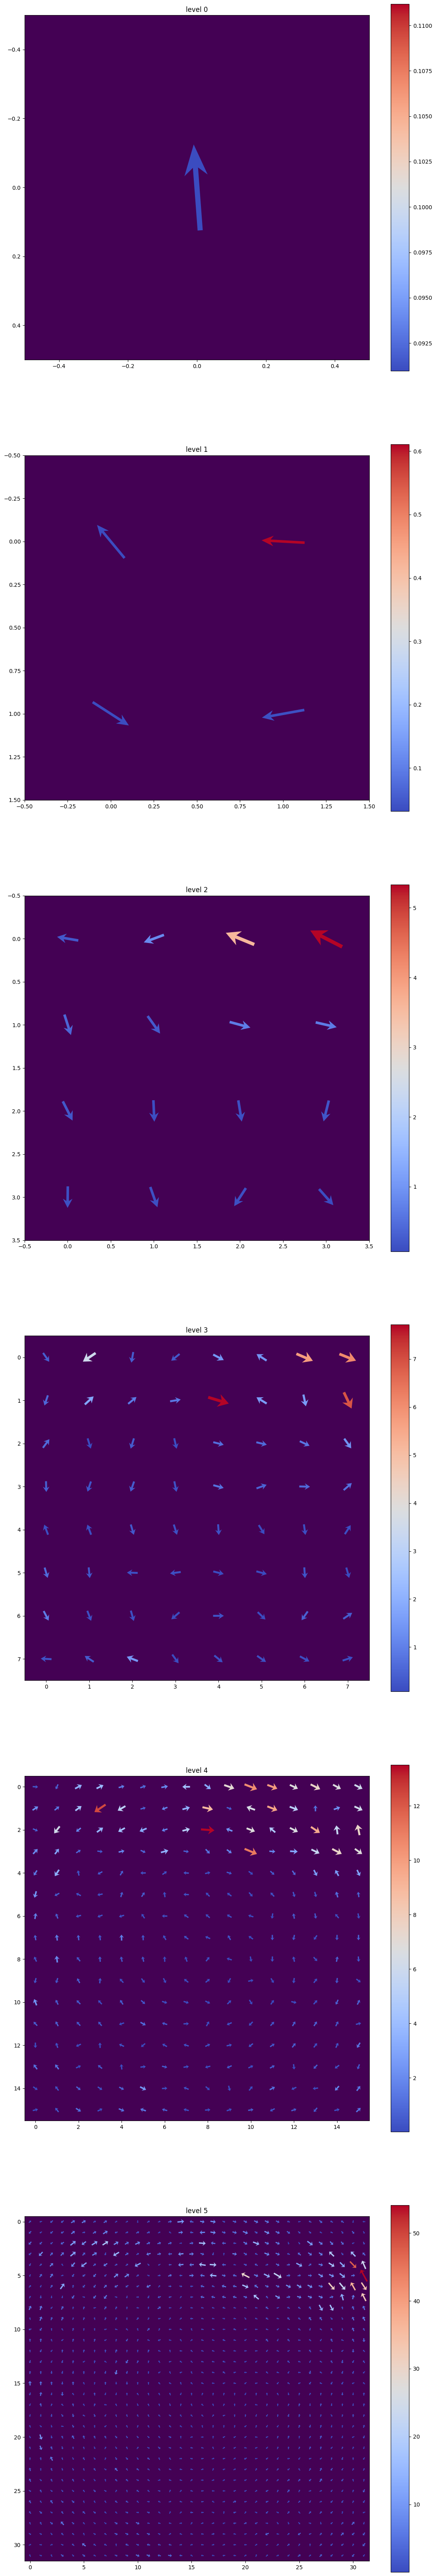

In [ ]:
import matplotlib.colors as mcolors
# src_transforms = "./data/test/2500_1144_transform_pyramid_quadtree_20k.pickle"
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement\results\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement\results_in_some_part\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement_point_to_point\results_in_some_part\pyramid_transforms_test.pickle"
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\results\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\test_small_sample\level_3\results\pyramid_transforms_test.pickle"
with open(src_transforms, 'rb') as f:
    lst_transforms = pickle.load(f)

data = []
lvl = 0
storage = []
max_lvl = max(set([x[0] for x in lst_transforms])) + 1
fig, axs = plt.subplots(max_lvl, 1, figsize=(14, max_lvl*14))
# fig, axs = plt.subplots(1, 2, figsize=(14, 7))
while len(storage) < len(lst_transforms):
    X, Y, U, V, norms = [], [], [], [] , []
    # transfert element of current lvl from storage to data 
    for el in [x for x in lst_transforms if x[0] == lvl]:
        storage.append(el)
    data = [x for x in storage if x[0] == lvl or x[-1] == True]

    size = 2**lvl
    tile_size = 1
    x_poses = np.array([x[1][0][0] for x in data])
    y_poses = np.array([x[1][0][1] for x in data])

    list_x_poses = sorted(list(set(x_poses)))
    list_y_poses = sorted(list(set(y_poses)))
    grid = np.zeros((size,size))
    for el in data:
        ix = size - list_y_poses.index(el[1][0][1]) - 1
        iy = list_x_poses.index(el[1][0][0])

        # translation:
        transform = el[1][3]
        norm = np.linalg.norm(transform[0:2,3])
        norms.append(float(norm))
        direction = transform[0:2,3] / norm * tile_size / 2
        val = np.linalg.norm(transform[0:3, 3])
        val=0
        tile_size = 2**(lvl - el[0])
        grid[ix:ix+tile_size,iy:iy+tile_size] = val


        # store vector at tile center
        cx = iy
        cy = ix

        X.append(cx)
        Y.append(cy)
        U.append(direction[0])
        V.append(-direction[1])  # minus because imshow flips Y axis
    lvl_factor = np.clip(lvl/max_lvl * 3, 0.5, 3)
    # lvl=0
    axs[lvl].set_title(f'level {lvl}')
    im = axs[lvl].imshow(grid)

    # show arrows
    bins = [0, 1, 2, 3, 5, 7, 10, 20, 50, 100, np.inf]  # adjust to your data
    # importance_factor = [1,2,3]
    importance_factor = np.arange(1, 2, 1/10)
    scales = np.arange(2, 0.001, -1.999/10)
    print(scales)
    arrow_heads_w_l = [(x,y) for x,y in zip(np.arange(3,0.1,-2.9/10), np.arange(5,0.1,-4.9/10))]
    # print(importance_factor.shape)
    X = np.array(X)
    Y = np.array(Y)
    U = np.array(U)
    V = np.array(V)
    norms = np.array(norms)

    for i in range(len(importance_factor)):
        mask = (norms >= bins[i]) & (norms < bins[i+1])
        w = 0.03/size * lvl_factor * importance_factor[i]
        qu = axs[lvl].quiver(
            X[mask], Y[mask], U[mask], V[mask], norms[mask],
            color='white',
            scale=scales[i],          # adjust this!
            scale_units='xy',
            angles='xy',
            pivot='middle',
            width=w,
            headwidth=3 / 1.1**lvl * (importance_factor[i]+0.5),
            headlength=4 / 1.3**lvl * (importance_factor[i]+0.5),
            headaxislength= 3 / 1.3**lvl * (importance_factor[i]+0.5),
            cmap="coolwarm",
            norm=mcolors.Normalize(vmin=np.min(norms), vmax=np.max(norms))
        )
    
    cbar = axs[lvl].figure.colorbar(qu, ax=axs[lvl])
    # cbar = axs[lvl].figure.colorbar(im, ax=axs[lvl])
    lvl += 1
    # break

level:  0
0 - 0
2588950.25 - 1168950.25
val: 94.75414481377544
fitness: 0.9632202479338843
rmse: 0.15103053045028772
[[ 9.99999999e-01 -3.15468833e-05  1.24937148e-05  3.68879341e+01]
 [ 3.15468980e-05  1.00000000e+00 -1.17761979e-06 -8.15892868e+01]
 [-1.24936776e-05  1.17801393e-06  1.00000000e+00  3.09970410e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
---


TypeError: 'Axes' object is not subscriptable

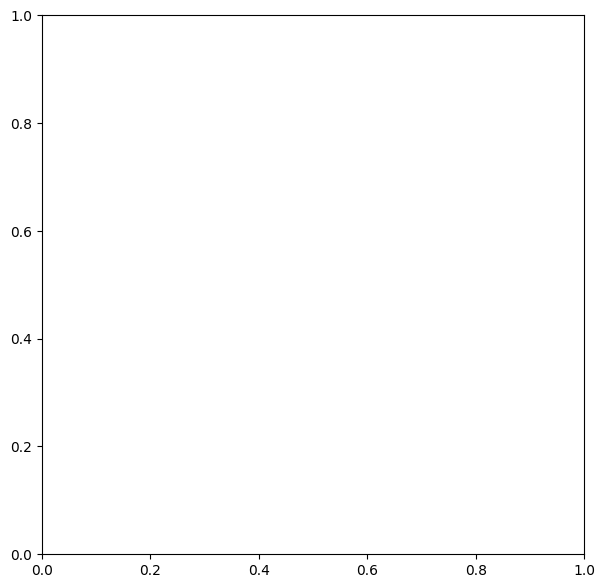

In [ ]:
# src_transforms = "./data/test/2500_1144_transform_pyramid_quadtree_20k.pickle"
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement\results\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement\results_in_some_part\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_artificial_movement_point_to_point\results_in_some_part\pyramid_transforms_test.pickle"
src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\results\pyramid_transforms_test.pickle"
# src_transforms = r"D:\GitHubProjects\Terranum_repo\pc_movement_tracking\data\test_real_movement\test_small_sample\level_3\results\pyramid_transforms_test.pickle"
with open(src_transforms, 'rb') as f:
    lst_transforms = pickle.load(f)

# xbase = 2500000
# ybase = 1144000
data = []
lvl = 0
storage = []
max_lvl = max(set([x[0] for x in lst_transforms])) + 1
fig, axs = plt.subplots(max_lvl, 1, figsize=(7, max_lvl*7))
while len(storage) < len(lst_transforms):
    print("level: ", lvl)
    # transfert element of current lvl from storage to data 
    for el in [x for x in lst_transforms if x[0] == lvl]:
        storage.append(el)
    data = [x for x in storage if x[0] == lvl or x[-1] == True]

    size = 2**lvl
    x_poses = np.array([x[1][0][0] for x in data])
    y_poses = np.array([x[1][0][1] for x in data])

    list_x_poses = sorted(list(set(x_poses)))
    list_y_poses = sorted(list(set(y_poses)))
    grid = np.zeros((size,size))
    for el in data:
        ix = size - list_y_poses.index(el[1][0][1]) - 1
        iy = list_x_poses.index(el[1][0][0])
        # position:
        # val = el[1][0][0] + el[1][0][1]

        # translation:
        transform = el[1][3]
        val = np.sqrt(np.sum(transform[0:3,3]**2))
        # val = np.sum(transform[0:3,3])

        size = 2**(lvl - el[0])
        grid[ix:ix+size,iy:iy+size] = val
        print(ix, '-', iy)
        print(el[1][0][0], '-', el[1][0][1])
        print("val:", val)
        print("fitness:" , el[1][1])
        print("rmse:" , el[1][2])
        print(transform)
        # print(transform[0:3,3])
    print('---')
    axs[lvl].set_title(f'level {lvl}')
    im = axs[lvl].imshow(grid)
    cbar = axs[lvl].figure.colorbar(im, ax=axs[lvl])
    lvl += 1
    # remove element of data that is not last
    # for el in [x for x in data if x[-1] == False]:
    #     print(el)
    #     data.remove(el)
        # print(len(data))